# Model evaluation 

For model evaluation, positive and negative datasets were obtained from `UniProt`. Review entries with Pfam PF00014 annotation were labeled as the positive set. A total of 398 entries were obtain

```
(reviewed:true) AND (xref:pfam-PF00014)
```

For the negative set, review entries not annotated as Kunitz domains were used. 574,229 entries were retrieved. 

```
(reviewed:true) NOT (xref:pfam-PF00014)
````

`HMMsearch`, from `hmmer` was then performed on both sets using the trained HMM model. The effective size of the data base was fix at 1000 (`-Z 1000`) sequence, to ensure that the E-value obtain from both set is comparable. Since the calculation depended on the total sequence in the set and
fixing the E-value will neglect the positive and negative class imbalance. Additional, due to the quantity of data the printing of the aligment was deactivated (`--noali`). With `--max` the heuristic filter were deactivated to maximize the sensibility of detecting coincident between the model and the querying sequence. 

```bash
# Running the hmmsearch with the mtm model in the positive set
hmmsearch -Z 1000 --noali --max --tblout kunitz_table_positive.txt kunitz_model_mtm.hmm UniprotSearch/positive

# Running the hmmsearch with the mtm model in the negative set
hmmsearch -Z 1000 --noali --max --tblout kunitz_table_negatives.txt kunitz_model_mtm.hmm UniprotSearch/negatives
```

For the negative set, the output was parsed into a csv file containing the PDB accession, e-values, scores, biases, (all set at 0) and the corresponding labels (1 for positive, 0 for negative).

```bash
# Exctracting the ids of the sequences in the negative set, later will be used to build the negative set
! grep ">" UniprotSearch/negatives | awk '{print $1}'| tr -d ">" | sort > negatives_kunitz.ids

! awk '{print $1 " 100 0 0 0"}' negatives_kunitz.ids > negatives_kunitz.csv
```

## Construction of positive set

In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc, roc_auc_score
from pathlib import Path
import matplotlib.pyplot as plt

Positive set was retrieve from the positive examples previously score by the HMM model. The accession id, the E-value, the score and the bias were pars from the original file. An additional column (label) was included an set as "1" to tag the positive example for further analysis. 

In [16]:
#Extracting information from the hmmsearch output tables for the full sequences
cols = ["accession", "e_value", "score", "bias"]

df_positive = pd.read_csv('Files/kunitz_table_positive.txt',sep=r'\s+', comment='#', header=None, usecols=[0, 4, 5, 6], names=cols)
df_positive['label'] = 1      # Label for positive hits is 1
df_positive['accession'] = df_positive['accession'].str.split('|').str[1]
df_positive.sort_values(by='e_value', inplace=True)
df_positive


,accession,e_value,score,bias,label
0,Q868Z9,4.600000e-189,608.6,187.0,1
1,O76840,2.000000e-180,580.9,134.4,1
2,A0A6P8HC43,3.100000e-94,304.8,61.0,1
3,Q02445,9.000000e-67,216.8,36.2,1
4,P10646,1.100000e-66,216.6,35.0,1
...,...,...,...,...,...
393,Q11101,2.700000e-07,26.3,7.7,1
394,Q8WPG5,2.100000e-05,20.3,4.7,1
395,A0A1Q1NL17,3.500000e-04,16.3,4.7,1
396,O62247,2.200000e-03,13.8,1.0,1


In [17]:
print( "The obtained positive entries were: " + str(df_positive.shape[0]))

The obtained positive entries were: 398


To avoid possible overfitting, the first 3 entries, order by E-value, were remove, since they could be use in the training of the model

In [18]:
df_positive = df_positive[3:]
df_positive

,accession,e_value,score,bias,label
3,Q02445,9.000000e-67,216.8,36.2,1
4,P10646,1.100000e-66,216.6,35.0,1
5,Q28864,1.100000e-66,216.5,35.4,1
6,P19761,1.100000e-65,213.3,33.2,1
7,O54819,7.900000e-65,210.6,35.0,1
...,...,...,...,...,...
393,Q11101,2.700000e-07,26.3,7.7,1
394,Q8WPG5,2.100000e-05,20.3,4.7,1
395,A0A1Q1NL17,3.500000e-04,16.3,4.7,1
396,O62247,2.200000e-03,13.8,1.0,1


In [10]:
print( "The obtained positive entries were after filtering: " + str(df_positive.shape[0]))

The obtained positive entries were after filtering: 395


## Construction of the negative set

Negative set was retrieve from the negatives examples previously score by the HMM model. The accession id, the E-value, the score and the bias were pars from the original file. An additional column (label) was included an set as "0" to tag the positive example for further analysis. 

In [19]:
df_negative = pd.read_csv('Files/kunitz_table_negatives.txt',sep=r'\s+', comment='#', header=None, usecols=[0, 4, 5, 6], names=cols)
df_negative['label'] = 0      # Label for negative hits is 0'
df_negative['accession'] = df_negative['accession'].str.split('|').str[1]
df_negative.sort_values(by='e_value', inplace=True)
df_negative

,accession,e_value,score,bias,label
0,P84555,6.400000e-07,25.1,0.0,0
1,P83605,1.500000e-05,20.8,0.1,0
2,P0DJ63,3.300000e-05,19.6,0.1,0
3,Q09JW3,9.800000e-05,18.1,4.1,0
4,Q09JW4,1.100000e-04,18.0,5.0,0
...,...,...,...,...,...
5497,O88273,1.000000e+01,2.1,0.2,0
5498,P80351,1.000000e+01,2.1,0.1,0
5499,P04759,1.000000e+01,2.1,0.4,0
5500,P29774,1.000000e+01,2.1,0.2,0


In [12]:
print( "The obtained negative entries were: " + str(df_negative.shape[0]))

The obtained negative entries were: 5502


The obtain data frame are the entries that received a score in the `HMMsearch`, so the maximum E-value available is 1. For the negatives example that are not matching according to de model a fictional E-value of 100 was fix. A data frame was build from the negative accession, previously build with fictional values.

In [20]:
# Integrating the negatives ids that did not have hits in the hmmsearch output
cols = ["accession", "e_value", "score", "bias", "label"]
negatives_kunitz_ids = pd.read_csv('Files/negatives_kunitz.csv',sep=' ', header=None, names=cols, index_col=False)
negatives_kunitz_ids

,accession,e_value,score,bias,label
0,A0A009IHW8,100,0,0,0
1,A0A011QK89,100,0,0,0
2,A0A017SE81,100,0,0,0
3,A0A017SE85,100,0,0,0
4,A0A017SEF3,100,0,0,0
...,...,...,...,...,...
574224,X5LX76,100,0,0,0
574225,X5M5N0,100,0,0,0
574226,X5M8U1,100,0,0,0
574227,X6R8D5,100,0,0,0


The negatives dataset were merge so the E-values of the negatives accessions that had a hit in the HMMsearch could be correctly update

In [21]:
# converting the values from string to float
negatives_kunitz_ids['e_value'] = negatives_kunitz_ids['e_value'].astype(float)
negatives_kunitz_ids['score'] = negatives_kunitz_ids['score'].astype(float)
negatives_kunitz_ids['bias'] = negatives_kunitz_ids['bias'].astype(float)

# Updating the negative DataFrame with the negatives that did not have hits in the hmmsearch output
df_negative.set_index('accession', inplace=True)
negatives_kunitz_ids.set_index('accession', inplace=True)
negatives_kunitz_ids.update(df_negative)

# Displaying the values
negatives_kunitz_ids.sort_values(by='e_value', inplace=True)
negatives_kunitz_ids

,e_value,score,bias,label
accession,,,,
P84555,6.400000e-07,25.1,0.0,0
P83605,1.500000e-05,20.8,0.1,0
P0DJ63,3.300000e-05,19.6,0.1,0
Q09JW3,9.800000e-05,18.1,4.1,0
Q09JW4,1.100000e-04,18.0,5.0,0
...,...,...,...,...
X5M5N0,1.000000e+02,0.0,0.0,0
X5M8U1,1.000000e+02,0.0,0.0,0
X6R8D5,1.000000e+02,0.0,0.0,0


In [22]:
negatives_kunitz_ids = negatives_kunitz_ids.reset_index()

In [24]:
print( "The obtained negative entries after the merge were: " + str(negatives_kunitz_ids.shape[0]))

The obtained negative entries after the merge were: 574229


## Cross-validation sets

The combined datasets were shuffled and split into two halves for cross-validation. The first set will be used to determine the optimal E-value threshold, ranging from $10^{-1}$ to $10^{-14}$. The second set will then be used to evaluate the actual performance of the model in predicting labels (Kunitz or non-Kunitz) using the optimized E-value threshold derived from the first set.

In [28]:
df_positive_shuffled = df_positive.sample(frac=1, random_state=42).reset_index(drop=True)
df_negative_shuffled = negatives_kunitz_ids.sample(frac=1, random_state=42).reset_index(drop=True)

df_total= pd.concat([df_positive_shuffled, df_negative_shuffled], ignore_index=True)

In [29]:
print( "The total number of entries in the dataset is: " + str(df_total.shape[0]))

The total number of entries in the dataset is: 574624


## Model evaluation

For the threshold determination the 2 subsets were separate as cross validation sets and a range of threshold between $10^{-1}$ and $10^{-15}$ was used. The selected threshold was the one that maximizes the Mathew correlation coefficient (MCC). Other metrics such as the accuracy and the F1 score were computed as well.

In [39]:
e_values = df_total['e_value'].values
labels = df_total['label'].values

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(skf.split(e_values, labels), 1):
    e_values_train, labels_train = e_values[train_idx], labels[train_idx]
    e_values_test, labels_test = e_values[test_idx], labels[test_idx]

    #Threshold optimization on the training 
    best_threshold = 1.0
    best_mcc = -1.0
    
    for exp in range(0, 15):
        threshold = 10.0**(-exp)
        predicted = (e_values_train < threshold).astype(int)
        mcc_value = matthews_corrcoef(labels_train, predicted)
        
        if mcc_value > best_mcc:
            best_mcc = mcc_value
            best_threshold = threshold
            
    # Threshold evaluation on the test
    predicted_test = (e_values_test < best_threshold).astype(int)
    
    test_mcc = matthews_corrcoef(labels_test, predicted_test)
    test_acc = accuracy_score(labels_test, predicted_test)
    test_f1 = f1_score(labels_test, predicted_test)
    
    fold_metrics.append({'fold': fold, 'threshold': best_threshold, 'mcc': test_mcc, 'acc': test_acc, 'f1': test_f1})
    
fold_metrics = pd.DataFrame(fold_metrics)

print("The optimal threshold was: 10^"+str(np.round(np.log10(fold_metrics['threshold'].mean()))))
print( "MCC:  "+str(fold_metrics['mcc'].mean()) )
print( "Accuracy: "+str(fold_metrics['acc'].mean()) )
print( "F1 Score:" +str(fold_metrics['f1'].mean()) )
    
    

The optimal threshold was: 10^-5.0
MCC:  0.9910630341946767
Accuracy: 0.9999878181210671
F1 Score:0.9910085953932848


As evidence by the ROC curve, the classification was highly accurate

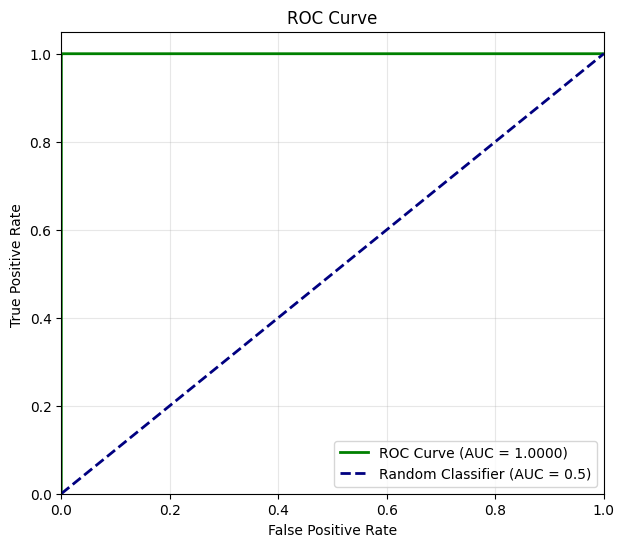

In [53]:
scores_test = -np.log10(e_values_test + 1e-300)

# False positive and false 
fpr, tpr, thresholds = roc_curve(labels_test, scores_test)
roc_auc = auc(fpr, tpr)  

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate ')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

### Confusion matrix

The confusion matrix was also computed bas con the correct and incorrect predictions made by the HMM model. 6 sequences were identify as false negatives.

In [46]:

cm_df = pd.crosstab(labels_test, predicted_test, 
    rownames=['Actual'], colnames=['Predicted'])

cm_df.index = ['actual negative', 'actual positive']
cm_df.columns = ['predicted negative', 'predicted positive']

print(cm_df)

                 predicted negative  predicted positive
actual negative              287115                   0
actual positive                   6                 191


In [48]:
false_negative = df_total[(df_total['label'] == 1) & (df_total['e_value'] >= best_threshold)]
false_negative

,accession,e_value,score,bias,label
4,Q11101,2.700000e-07,26.3,7.7,1
13,O62247,2.200000e-03,13.8,1.0,1
21,Q8WPG5,2.100000e-05,20.3,4.7,1
133,P86963,1.400000e-07,27.3,9.4,1
360,A0A1Q1NL17,3.500000e-04,16.3,4.7,1
387,D3GGZ8,1.200000e-01,8.3,3.4,1


After the revision of the accession in UniProt, the proteins were mark as Kunitz domain by other databases (InterPro or Prosite), the misclassification could be cause by the loop structure of the protein or the atypical cysteine localization in the sequence. 